<a href="https://colab.research.google.com/github/Shubz15/Machine-Learning-Training/blob/main/Exp_5/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
data = pd.read_csv("loan_approval_dataset.csv")
print("First 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns)
print("\nDataset Shape:")
print(data.shape)


First 5 rows:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0           

In [3]:
le = LabelEncoder()
data[' education'] = le.fit_transform(data[' education'])
data[' self_employed'] = le.fit_transform(data[' self_employed'])
data[' loan_status'] = le.fit_transform(data[' loan_status'])
print("After Encoding:")
print(data.head())


After Encoding:
   loan_id   no_of_dependents   education   self_employed   income_annum  \
0        1                  2           0               0        9600000   
1        2                  0           1               1        4100000   
2        3                  3           0               0        9100000   
3        4                  3           0               0        8200000   
4        5                  5           1               1        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  176

In [4]:
data = data.drop('loan_id', axis=1)
print(data.columns)

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [5]:
X = data.drop(' loan_status', axis=1)
Y = data[' loan_status']

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
 X, Y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)


LogisticRegression(max_iter=1000)

In [9]:
Y_pred = model.predict(X_test_scaled)
print(Y_pred[:10])


[1 0 1 0 0 0 0 1 0 1]


In [10]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)
print(confusion_matrix(Y_test, Y_pred))


Accuracy: 0.905152224824356
[[498  38]
 [ 43 275]]


In [11]:
new_data = [[2, 0, 0, 5000000, 15000000, 10, 750, 3000000, 2000000, 10000000, 4000000]]
new_data_df = pd.DataFrame(new_data, columns=X.columns)
new_data_scaled = scaler.transform(new_data_df)
prediction = model.predict(new_data_scaled)
print("Prediction (0=Approved, 1=Rejected):", prediction[0])

Prediction (0=Approved, 1=Rejected): 0


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

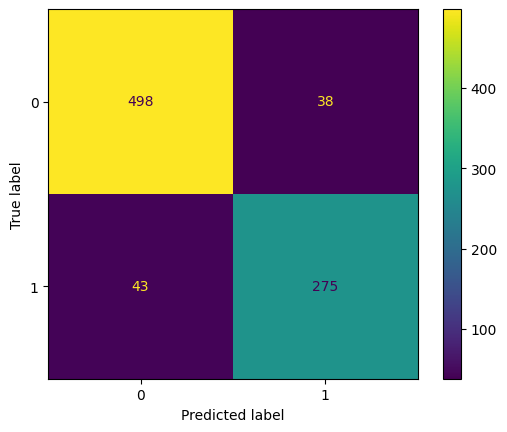

In [17]:
# Confusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)
plt.show()




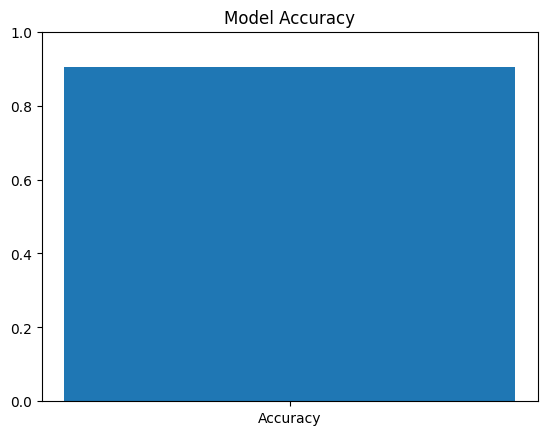

In [18]:
# Accuracy Visualization
plt.bar(["Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()


   Actual  Predicted
0       1          1
1       0          0
2       1          1
3       0          0
4       0          0
5       0          0
6       0          0
7       1          1
8       0          0
9       1          1


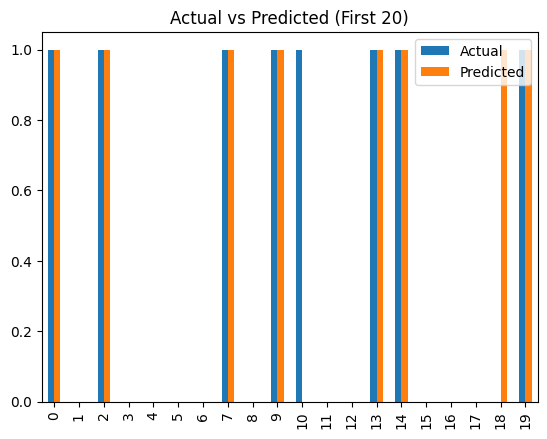

In [20]:
# Actual vs Predicted Comparison
comparison = pd.DataFrame({"Actual": Y_test.values, "Predicted": Y_pred})
print(comparison.head(10))

comparison.head(20).plot(kind='bar')
plt.title("Actual vs Predicted (First 20)")
plt.show()


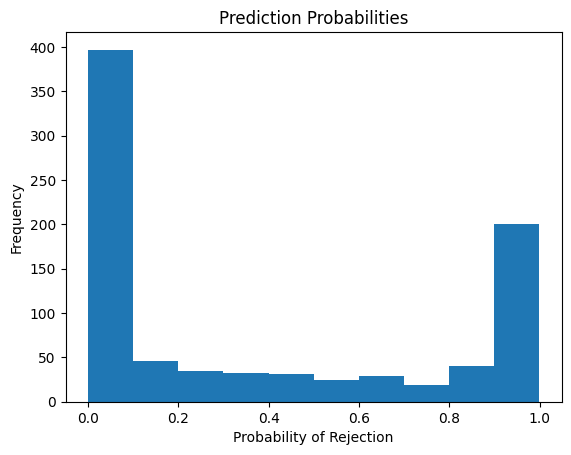

In [21]:
# Probability Visualization
Y_prob = model.predict_proba(X_test_scaled)[:, 1]
plt.hist(Y_prob, bins=10)
plt.title("Prediction Probabilities")
plt.xlabel("Probability of Rejection")
plt.ylabel("Frequency")
plt.show()


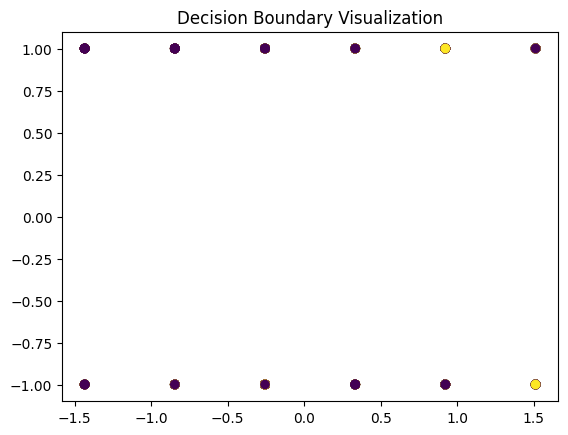

In [22]:
# Decision Boundary (Optional)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=Y_pred)
plt.title("Decision Boundary Visualization")
plt.show()